In [1]:
import pandas as pd

In [2]:
BaCus = pd.read_csv('customer_booking.csv', encoding='latin1')

In [3]:
BaCus.head(20).T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
num_passengers,2,1,2,1,2,1,3,2,1,1,2,1,4,1,1,1,1,1,1,1
sales_channel,Internet,Internet,Internet,Internet,Internet,Internet,Internet,Internet,Internet,Mobile,Internet,Internet,Internet,Internet,Internet,Internet,Internet,Internet,Internet,Internet
trip_type,RoundTrip,RoundTrip,RoundTrip,RoundTrip,RoundTrip,RoundTrip,RoundTrip,RoundTrip,RoundTrip,RoundTrip,RoundTrip,RoundTrip,RoundTrip,RoundTrip,RoundTrip,RoundTrip,RoundTrip,RoundTrip,RoundTrip,RoundTrip
purchase_lead,262,112,243,96,68,3,201,238,80,378,185,8,265,185,245,192,259,19,67,351
length_of_stay,19,20,22,31,22,48,33,19,22,30,25,43,24,17,34,18,37,29,155,17
flight_hour,7,3,17,4,15,20,6,14,4,12,14,2,19,14,4,14,6,10,8,3
flight_day,Sat,Sat,Wed,Sat,Wed,Thu,Thu,Mon,Mon,Sun,Tue,Sat,Mon,Fri,Tue,Thu,Sun,Sat,Sun,Sun
route,AKLDEL,AKLDEL,AKLDEL,AKLDEL,AKLDEL,AKLDEL,AKLDEL,AKLDEL,AKLDEL,AKLDEL,AKLDEL,AKLDEL,AKLDEL,AKLDEL,AKLDEL,AKLDEL,AKLDEL,AKLDEL,AKLDEL,AKLHGH
booking_origin,New Zealand,New Zealand,India,New Zealand,India,New Zealand,New Zealand,India,New Zealand,India,United Kingdom,New Zealand,New Zealand,India,New Zealand,India,India,New Zealand,New Zealand,China
wants_extra_baggage,1,0,1,0,1,1,1,1,0,0,1,1,1,0,1,1,0,0,1,0


In [4]:
BaCus.shape

(50000, 14)

In [5]:
BaCus.dtypes

num_passengers             int64
sales_channel             object
trip_type                 object
purchase_lead              int64
length_of_stay             int64
flight_hour                int64
flight_day                object
route                     object
booking_origin            object
wants_extra_baggage        int64
wants_preferred_seat       int64
wants_in_flight_meals      int64
flight_duration          float64
booking_complete           int64
dtype: object

In [6]:
BaCus.isnull().sum()

num_passengers           0
sales_channel            0
trip_type                0
purchase_lead            0
length_of_stay           0
flight_hour              0
flight_day               0
route                    0
booking_origin           0
wants_extra_baggage      0
wants_preferred_seat     0
wants_in_flight_meals    0
flight_duration          0
booking_complete         0
dtype: int64

In [7]:
# 1. Target balance
print(BaCus['booking_complete'].value_counts())
print(BaCus['booking_complete'].value_counts(normalize=True) * 100)

# 2. Categorical unique values
print(BaCus['sales_channel'].unique())
print(BaCus['trip_type'].unique())
print(BaCus['flight_day'].unique())

booking_complete
0    42522
1     7478
Name: count, dtype: int64
booking_complete
0    85.044
1    14.956
Name: proportion, dtype: float64
['Internet' 'Mobile']
['RoundTrip' 'CircleTrip' 'OneWay']
['Sat' 'Wed' 'Thu' 'Mon' 'Sun' 'Tue' 'Fri']


In [8]:
 # 1. Check route and booking_origin unique counts
print(BaCus['route'].nunique())
print(BaCus['booking_origin'].nunique())

# 2. Basic statistics
print(BaCus.describe())

799
104
       num_passengers  purchase_lead  length_of_stay  flight_hour  \
count    50000.000000   50000.000000     50000.00000  50000.00000   
mean         1.591240      84.940480        23.04456      9.06634   
std          1.020165      90.451378        33.88767      5.41266   
min          1.000000       0.000000         0.00000      0.00000   
25%          1.000000      21.000000         5.00000      5.00000   
50%          1.000000      51.000000        17.00000      9.00000   
75%          2.000000     115.000000        28.00000     13.00000   
max          9.000000     867.000000       778.00000     23.00000   

       wants_extra_baggage  wants_preferred_seat  wants_in_flight_meals  \
count         50000.000000          50000.000000           50000.000000   
mean              0.668780              0.296960               0.427140   
std               0.470657              0.456923               0.494668   
min               0.000000              0.000000               0.00000

In [9]:
print(BaCus['route'].head(10))
print(BaCus['booking_origin'].head(10))

0    AKLDEL
1    AKLDEL
2    AKLDEL
3    AKLDEL
4    AKLDEL
5    AKLDEL
6    AKLDEL
7    AKLDEL
8    AKLDEL
9    AKLDEL
Name: route, dtype: object
0    New Zealand
1    New Zealand
2          India
3    New Zealand
4          India
5    New Zealand
6    New Zealand
7          India
8    New Zealand
9          India
Name: booking_origin, dtype: object


In [10]:
# Example structure for route
route_means = BaCus.groupby('route')['booking_complete'].mean()
BaCus['route_encoded'] = BaCus['route'].map(route_means)



In [11]:
origin_means = BaCus.groupby('booking_origin')['booking_complete'].mean()
BaCus['origin_encoded'] = BaCus['booking_origin'].map(origin_means)

# Now do the same for booking_origin yourself!

In [12]:
BaCus.drop(columns=['route', 'booking_origin'], inplace=True)

In [13]:
BaCus =pd.get_dummies(BaCus, columns=['sales_channel', 'trip_type', 'flight_day'])

In [14]:
print(BaCus.shape)
print(BaCus.dtypes)

(50000, 23)
num_passengers              int64
purchase_lead               int64
length_of_stay              int64
flight_hour                 int64
wants_extra_baggage         int64
wants_preferred_seat        int64
wants_in_flight_meals       int64
flight_duration           float64
booking_complete            int64
route_encoded             float64
origin_encoded            float64
sales_channel_Internet       bool
sales_channel_Mobile         bool
trip_type_CircleTrip         bool
trip_type_OneWay             bool
trip_type_RoundTrip          bool
flight_day_Fri               bool
flight_day_Mon               bool
flight_day_Sat               bool
flight_day_Sun               bool
flight_day_Thu               bool
flight_day_Tue               bool
flight_day_Wed               bool
dtype: object


In [15]:
#splitting data
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = BaCus.drop(columns=['booking_complete'])
y= BaCus['booking_complete']

X_train, X_val, y_train, y_val = train_test_split(X,y, test_size=0.2, random_state=42)

In [16]:
RF=RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

In [17]:
RF.fit(X_train,y_train)
y_pred= RF.predict(X_val)

In [18]:
from sklearn.metrics import classification_report, roc_auc_score
print(classification_report(y_val,y_pred))
print('ROC-AUC:', roc_auc_score(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.98      0.92      8520
           1       0.59      0.14      0.23      1480

    accuracy                           0.86     10000
   macro avg       0.73      0.56      0.58     10000
weighted avg       0.83      0.86      0.82     10000

ROC-AUC: 0.5632153280040604


In [19]:
from sklearn.model_selection import cross_val_score

In [21]:
scores = cross_val_score(RF, X, y, cv=5, scoring='f1')
print('F1 scores per fold:', scores)
print('Mean F1', scores.mean().round(3))

F1 scores per fold: [0.01584158 0.20158656 0.00508388 0.00815059 0.37748344]
Mean F1 0.122


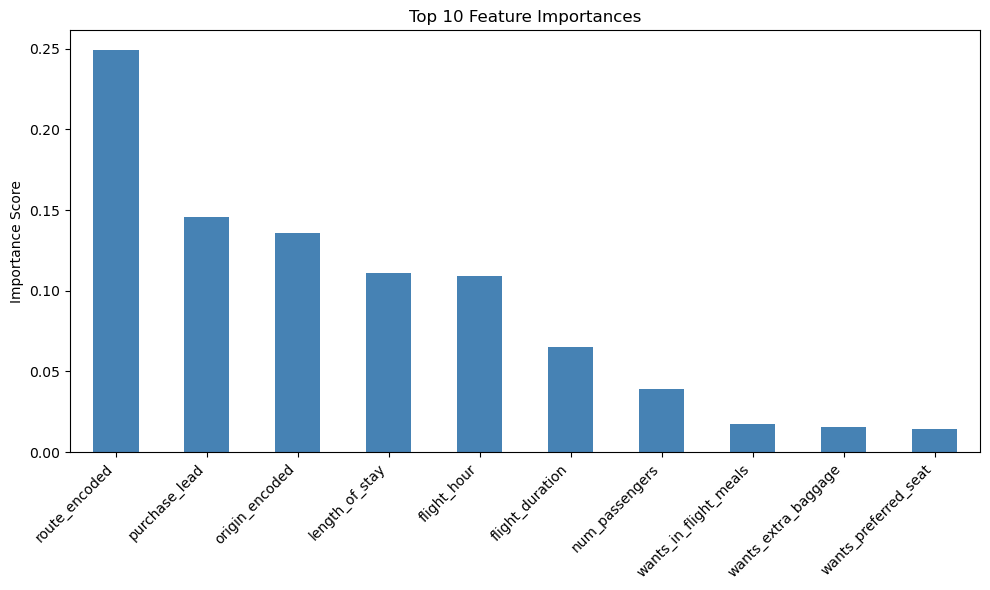

In [22]:
import matplotlib.pyplot as plt

# Get feature importances
importances = pd.Series(RF.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
importances.plot(kind='bar', color='steelblue')
plt.title('Top 10 Feature Importances')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()